In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

Modelo v2 de series temporales

### Objetivo

Predecir el precio de apertura en lugar del precio de cierre.

### Estrategia

Reducir dimensionalidad: Evitar tener mas de 10-15 variables originales (sin contar transformaciones)

Generar features parsimonicos: 1 o 2 lags por variable, 1 tasa de cambio o retorno, 1 promedio movil

In [2]:
df = pd.read_csv("../dataset.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [3]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [4]:
# df = df.loc[(df["fecha"] >= "2024-10-01") & (df["fecha"] <= "2025-06-30")].copy()

# mismo periodo que usamos en text mining

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [5]:
df = df.rename(columns={
    "merval_apertura": "merval",
})

# elimino la otra columna del merval que no vamos a usar
df = df.drop(columns=[
    "merval_total_return_ars",
    "merval_price_return_ars",
    "merval_cierre",
    "merval_maximo",
    "merval_minimo"
    ])

In [6]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [7]:
# chequeo de cuantos NAs tenemos en cada columna

pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval,0,0.0
embi_spread_arg,2,2.5
embi_spreads_brz,2,2.5
embi_spread_global,2,2.5
emae_original,0,0.0
emae_desestacionalizado,0,0.0
emae_tendencia_ciclo,0,0.0
tc_minorista,0,0.0
tc_mayorista,0,0.0


In [8]:
df.columns.tolist()

['fecha',
 'merval',
 'embi_spread_arg',
 'embi_spreads_brz',
 'embi_spread_global',
 'emae_original',
 'emae_desestacionalizado',
 'emae_tendencia_ciclo',
 'tc_minorista',
 'tc_mayorista',
 'rrii',
 'tamar',
 'badlar',
 'tm20',
 'tasa_depositos',
 'tasa_prestamos_personales',
 'base_monetaria',
 'circulacion_monetaria',
 'dep_ccorrientes',
 'dep_cahorro',
 'dep_plazo',
 'inflacion_rem',
 'cer',
 'uva',
 'm1',
 'm2',
 'm3']

In [9]:
# seleccion de variables originales

variables = [
 'fecha',
 'merval',
 'embi_spread_arg',
#  'embi_spreads_brz',
 'embi_spread_global',
#  'emae_original',
 'emae_desestacionalizado',
#  'emae_tendencia_ciclo',
 'tc_minorista',
 'tc_mayorista',
 'rrii',
 'tamar',
#  'badlar',
#  'tm20',
 'tasa_depositos',
 'tasa_prestamos_personales',
#  'base_monetaria',
#  'circulacion_monetaria',
#  'dep_ccorrientes',
#  'dep_cahorro',
#  'dep_plazo',
 'inflacion_rem',
 'cer',
#  'uva',
 'm1',
 'm2',
 'm3']

In [10]:
# Si imputamos deberiamos hacer una extrapolacion lineal entre los 2 valores que rodean al nulo probablemente

In [11]:
# Lags de 1, 2 y 7 días para las variables clave
lags = [1, 5]
cols = [
    'merval',
    'embi_spread_arg',
    #  'embi_spreads_brz',
    'embi_spread_global',
    #  'emae_original',
    # 'emae_desestacionalizado',
    #  'emae_tendencia_ciclo',
    'tc_minorista',
    'tc_mayorista',
    'rrii',
    'tamar',
    #  'badlar',
    #  'tm20',
    'tasa_depositos',
    'tasa_prestamos_personales',
    #  'base_monetaria',
    #  'circulacion_monetaria',
    #  'dep_ccorrientes',
    #  'dep_cahorro',
    #  'dep_plazo',
    # 'inflacion_rem',
    'cer',
    #  'uva',
    'm1',
    'm2',
    'm3']

for col in cols:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)


In [12]:
# variaciones porcentuales diarias

for col in cols:
    df[f"{col}_change"] = df[col].pct_change(fill_method=None).shift(1)


In [13]:
# promedio movil (calcula, para cada día t, el promedio de los t-3, t-2 y t-1)

for col in cols:
    df[f"{col}_ma3"] = df[col].rolling(window=3, min_periods=3).mean().shift(1)


In [14]:
# eliminar filas que quedaron con NAs luego de agregar lags, retornos, etc.
df = df.dropna().copy()

In [15]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha

## Train-Test Split

In [16]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(51, 77)
(13, 77)


## Cross-Validation

In [17]:
# Con 52 días hábiles, conviene usar menos pliegues y bloques de validación más cortos
# - n_splits=3: tres validaciones más estables
# - test_size=10: ~2 semanas hábiles de validación
# - gap=2: separación temporal entre train y test para evitar fuga de informacion

max_lag = 5

test_size = 10
# tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=0)
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)

In [18]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_distributions = {
    "n_estimators": randint(150, 401),
    "max_depth": randint(2, 11),
    "min_samples_split": randint(4, 21),
    "min_samples_leaf": randint(4, 13),
    "max_features": uniform(0.15, 0.35),
    "bootstrap": [True]
}

In [19]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # útil para auditar overfitting
    error_score=np.nan                       # si algún fold falla, no aborta toda la búsqueda
)

In [20]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Mejores hiperparámetros:", search.best_params_)
print("CV RMSE promedio:", -search.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 7, 'max_features': np.float64(0.16156775651519192), 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 296}
CV RMSE promedio: 171795.80559159533


## Test

In [21]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


Holdout RMSE: 75935.5539
Holdout R²:   -0.5498


In [22]:
rmse_rel = rmse / y_test.mean()
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Error relativo (holdout): 3.44%


1️⃣ El RMSE del holdout es bastante menor que el promedio de la CV

→ eso no suele ser malo (de hecho, es poco común).
Normalmente esperamos que el error en holdout sea igual o algo peor que en CV.
Que te haya dado menor puede significar varias cosas:

El conjunto de holdout (último 20%) fue más estable o menos volátil que los pliegues de CV.

Los pliegues usados en TimeSeriesSplit quizás contenían períodos más ruidosos (con saltos bruscos del MERVAL o variables exógenas).

También puede reflejar alta varianza en los splits (dataset chico → estimaciones de error inestables).

👉 En todo caso, no es un problema: el modelo parece comportarse igual o mejor en los últimos días que en las ventanas intermedias.

2️⃣ R² negativo (–0.55)

Esto sí es importante: un R² < 0 significa que el modelo predice peor que un modelo trivial que siempre pronostica la media del MERVAL.

Eso puede deberse a:

Ruido aleatorio muy alto (el MERVAL tiene días con saltos difíciles de predecir).

Muestra pequeña: 60–80 observaciones no alcanzan para estimar bien la varianza.

O bien a que el modelo se sobreadaptó en CV a patrones espurios y no los replicó en el holdout.

Pero ojo: el R² se castiga mucho con valores pequeños de y, y como el MERVAL tiene variaciones relativas pequeñas sobre un nivel alto (2 millones), incluso errores modestos hacen caer fuerte el R².

In [23]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

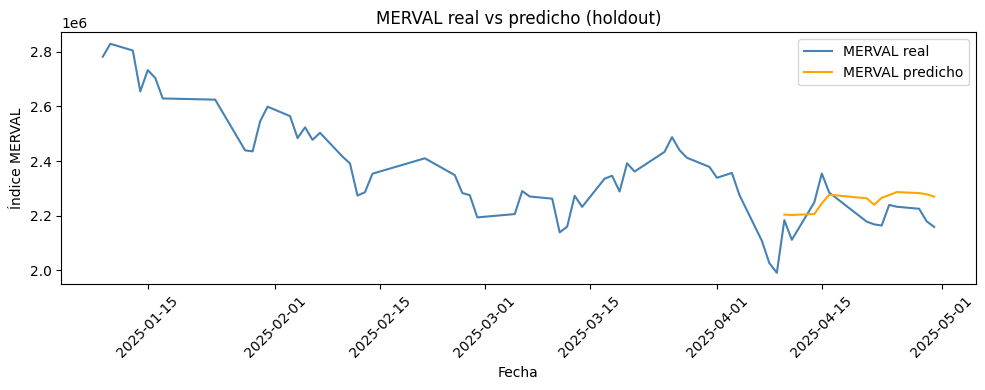

In [24]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


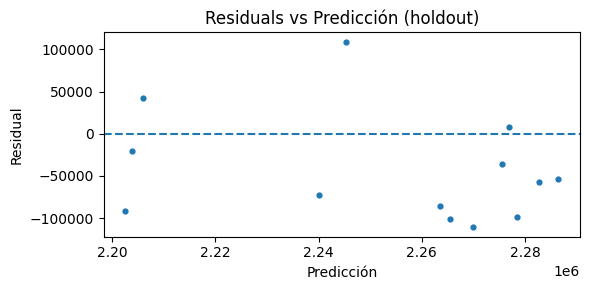

In [25]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


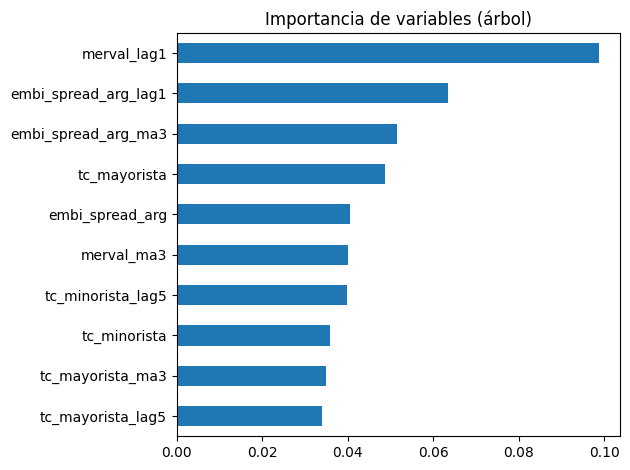

In [26]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()
